# W5 作业：二手车价格预测

**主题**：利用车辆属性预测二手车交易价格（回归任务）  
**模型**：传统机器学习（随机森林）+ 神经网络（MLP）  
**数据**：`data/car.csv`


## 步骤 1：理解实验任务与研究问题

- **任务类型**：监督学习中的**回归预测**，目标变量为二手车挂牌价格。  
- **研究问题**：哪些车辆属性（品牌、里程、燃料、变速箱、车龄、排量、座位数等）对价格影响最大？如何用模型对未知车辆给出合理估价？  
- **评价目标**：最小化预测误差（MAE、RMSE），并提高可解释方差（R²）。  
- **模型对比**：树模型擅长非线性与类别特征；神经网络可拟合复杂关系但需足够数据与调参。


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

ROOT = Path('.').resolve()
DATA_PATH = ROOT / 'data' / 'car.csv'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
CURRENT_YEAR = 2024
print('库导入完成')


库导入完成


## 步骤 2：读取数据集


In [2]:
df_raw = pd.read_csv(DATA_PATH, index_col=0)
print('数据路径:', DATA_PATH)
print('形状:', df_raw.shape)
df_raw.head()


数据路径: D:\OUC_machine_learning\W5_homework\data\car.csv
形状: (5512, 9)


,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


## 步骤 3：数据集基本信息


In [3]:
print('列名与类型:')
print(df_raw.dtypes)
print('\n缺失值:')
print(df_raw.isna().sum())
print('\n描述统计:')
df_raw.describe(include='all').T


列名与类型:
car_name                 str
car_prices_in_rupee      str
kms_driven               str
fuel_type                str
transmission             str
ownership                str
manufacture            int64
engine                   str
Seats                    str
dtype: object

缺失值:
car_name               0
car_prices_in_rupee    0
kms_driven             0
fuel_type              0
transmission           0
ownership              0
manufacture            0
engine                 0
Seats                  0
dtype: int64

描述统计:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,5512,1896,Maruti Alto 800 LXI,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_prices_in_rupee,5512,1300,4.50 Lakh,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_driven,5512,2610,"80,000 kms",163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,5512,5,Petrol,2967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,5512,2,Manual,3962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ownership,5512,6,1st Owner,3736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacture,5512.0,NaN,NaN,NaN,2015.455552,3.927974,1995.0,2013.0,2016.0,2018.0,2022.0
engine,5512,139,1197 cc,714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seats,5512,6,5 Seats,4673,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 步骤 4：数据预处理与清洗


In [4]:
def parse_price(s):
    s = str(s).strip()
    if 'Crore' in s:
        return float(s.replace('Crore', '').strip()) * 100
    if 'Lakh' in s:
        return float(s.replace('Lakh', '').strip())
    return float(s.replace(',', '')) / 100_000

def parse_kms(s):
    return float(str(s).replace(' kms', '').replace(',', '').strip())

def parse_engine(s):
    return float(str(s).replace(' cc', '').strip())

def parse_seats(s):
    return int(str(s).replace(' Seats', '').strip())

def extract_brand(name):
    return str(name).split()[0]

df = df_raw.copy()
df['price_lakh'] = df['car_prices_in_rupee'].map(parse_price)
df['kms'] = df['kms_driven'].map(parse_kms)
df['engine_cc'] = df['engine'].map(parse_engine)
df['seats_num'] = df['Seats'].map(parse_seats)
df['brand'] = df['car_name'].map(extract_brand)
df['car_age'] = CURRENT_YEAR - df['manufacture']

# 清洗：去除异常价格/里程
before = len(df)
df = df[(df['price_lakh'] > 0) & (df['price_lakh'] < 500) & (df['kms'] >= 0)]
print(f'清洗前 {before} 条，清洗后 {len(df)} 条')
df[['price_lakh','kms','engine_cc','seats_num','car_age','brand']].head()


清洗前 5512 条，清洗后 5512 条


,price_lakh,kms,engine_cc,seats_num,car_age,brand
0,10.03,86226.0,1956.0,5,7,Jeep
1,12.83,13248.0,1330.0,5,3,Renault
2,16.40,60343.0,2494.0,5,8,Toyota
3,7.77,26696.0,1199.0,5,6,Honda
4,5.15,69414.0,1199.0,5,8,Volkswagen


## 步骤 5：探索性数据分析（EDA）


In [5]:
num_cols = ['price_lakh','kms','manufacture','engine_cc','seats_num','car_age']
df[num_cols].describe()


,price_lakh,kms,manufacture,engine_cc,seats_num,car_age
count,5512.000000,5512.000000,5512.000000,5512.000000,5512.000000,5512.000000
mean,11.625096,63211.888062,2015.455552,1532.299710,5.250726,8.544448
std,19.699189,41844.131167,3.927974,579.210876,0.720075,3.927974
min,0.350000,250.000000,1995.000000,0.000000,2.000000,2.000000
25%,3.150000,33151.750000,2013.000000,1197.000000,5.000000,6.000000
50%,5.500000,59000.000000,2016.000000,1396.000000,5.000000,8.000000
75%,10.257500,84265.250000,2018.000000,1950.000000,5.000000,11.000000
max,192.000000,560000.000000,2022.000000,5950.000000,8.000000,29.000000


### 图1：价格分布直方图
**说明**：价格（Lakh）呈右偏分布，低价车数量多，高价豪华车较少，符合二手车市场结构。回归建模时可关注高价位样本误差。


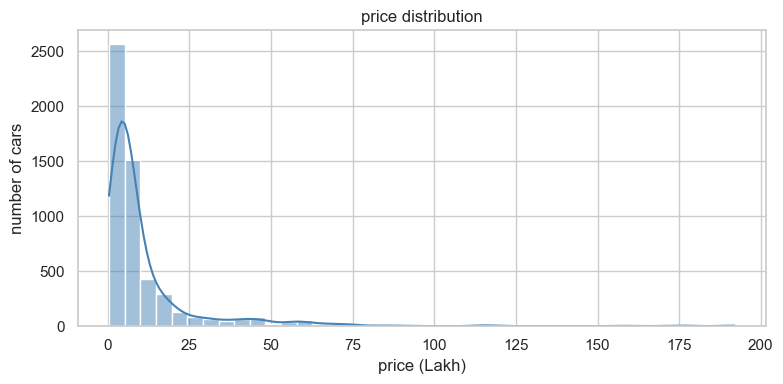

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['price_lakh'], bins=40, kde=True, color='steelblue')
plt.xlabel('price (Lakh)')
plt.ylabel('number of cars')
plt.title('price distribution')
plt.tight_layout()
plt.savefig(FIG_DIR/'01_price_dist.png', dpi=120)
plt.show()


### 图2：里程与价格散点图
**说明**：里程越高，价格整体呈下降趋势，体现折旧规律；同里程段价格仍较分散，说明品牌、年份等变量同样重要。


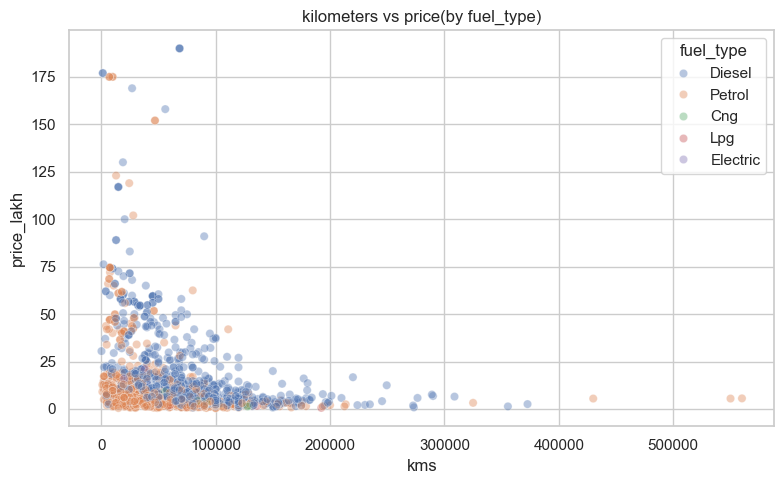

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(min(2000,len(df)), random_state=42), x='kms', y='price_lakh', alpha=0.4, hue='fuel_type')
plt.title('kilometers vs price(by fuel_type)')
plt.tight_layout()
plt.savefig(FIG_DIR/'02_kms_price.png', dpi=120)
plt.show()


### 图3：制造年份与价格箱线图
**说明**：年份越新（2018+）价格中位数越高；过旧车辆价格箱体下移，反映车龄对残值影响显著。


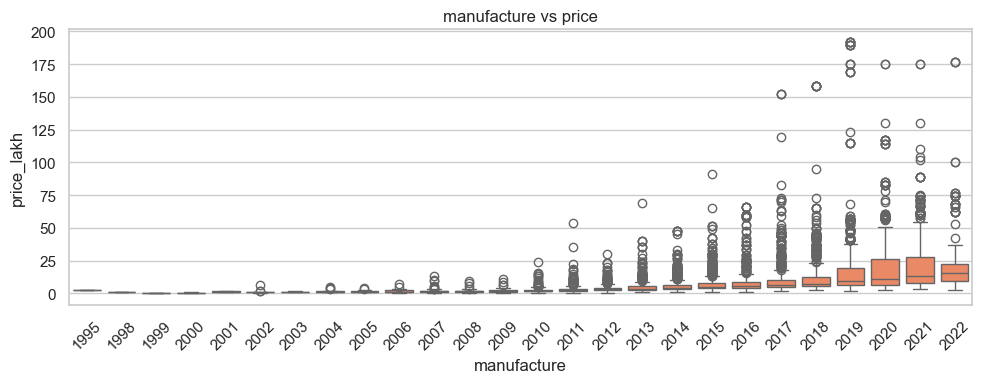

In [22]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='manufacture', y='price_lakh', color='coral')
plt.xticks(rotation=45)
plt.title('manufacture vs price')
plt.tight_layout()
plt.savefig(FIG_DIR/'03_year_price.png', dpi=120)
plt.show()


### 图4：燃料类型与变速箱的价格分布
**说明**：柴油/汽油、自动/手动对价格分布有差异；自动挡中位价通常高于手动挡，可作为重要类别特征。


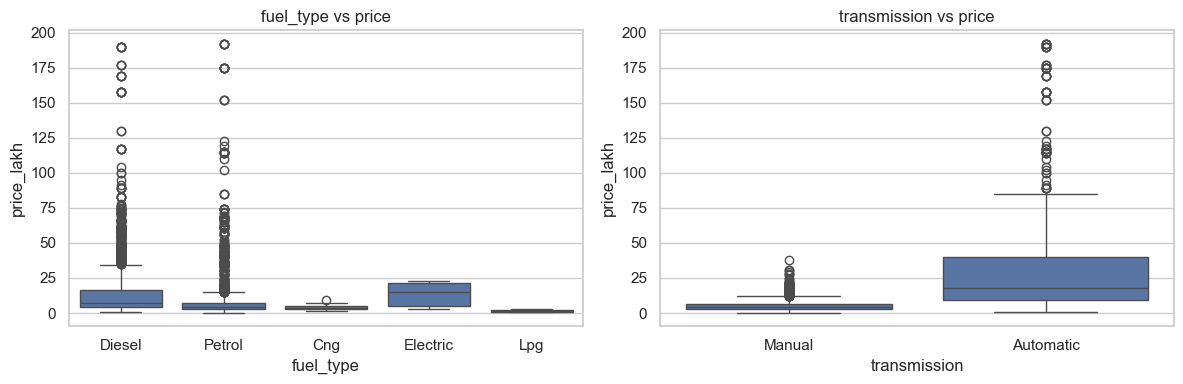

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='fuel_type', y='price_lakh', ax=axes[0])
axes[0].set_title('fuel_type vs price')
sns.boxplot(data=df, x='transmission', y='price_lakh', ax=axes[1])
axes[1].set_title('transmission vs price')
plt.tight_layout()
plt.savefig(FIG_DIR/'04_fuel_trans.png', dpi=120)
plt.show()


### 图5：相关性热力图
**说明**：`price_lakh` 与 `manufacture`（年份）、`engine_cc` 正相关，与 `kms`、`car_age` 负相关，为后续特征筛选提供依据。


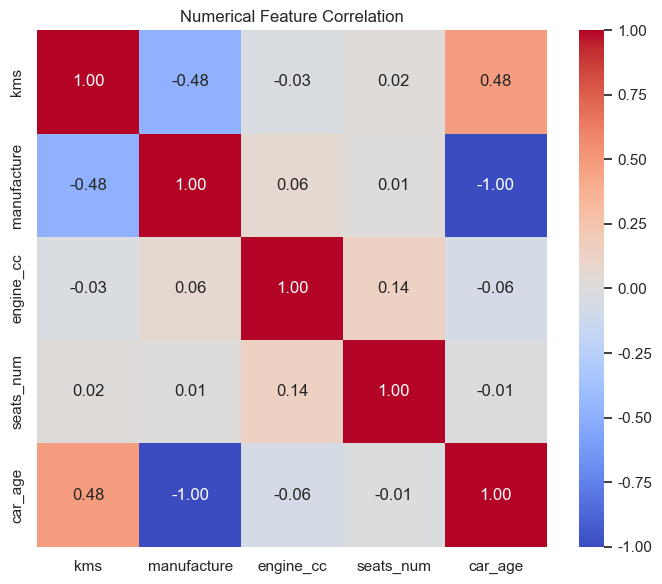

In [24]:
plt.figure(figsize=(7,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlation')
plt.tight_layout()
plt.savefig(FIG_DIR/'05_corr.png', dpi=120)
plt.show()


## 步骤 7：特征筛选


In [11]:
# 目标：price_lakh
# 剔除原始文本列 car_name、car_prices_in_rupee、kms_driven、engine、Seats
# 保留：brand, kms, fuel_type, transmission, ownership, manufacture, engine_cc, seats_num, car_age

target = 'price_lakh'
feature_cols = ['brand','kms','fuel_type','transmission','ownership','manufacture','engine_cc','seats_num','car_age']

corr_target = df[feature_cols + [target]].corr(numeric_only=True)[target].drop(target).sort_values(key=abs, ascending=False)
print('与价格的相关性（数值特征）:')
print(corr_target)
print('\n最终建模特征:', feature_cols)

X = df[feature_cols]
y = df[target]


与价格的相关性（数值特征）:
manufacture    0.351760
car_age       -0.351760
kms           -0.242475
engine_cc      0.164781
seats_num      0.006138
Name: price_lakh, dtype: float64

最终建模特征: ['brand', 'kms', 'fuel_type', 'transmission', 'ownership', 'manufacture', 'engine_cc', 'seats_num', 'car_age']


## 步骤 8：划分训练集与测试集（8:2）


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print('训练集:', X_train.shape, '测试集:', X_test.shape)


训练集: (4409, 9) 测试集: (1103, 9)


## 步骤 9：模型训练与评估

评价指标：**MAE、MSE、RMSE、R²、MAPE**。


In [25]:
cat_cols = ['brand','fuel_type','transmission','ownership']
num_cols = ['kms','manufacture','engine_cc','seats_num','car_age']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols),
])

def regression_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'模型': name, 'MAE': round(mae,4), 'MSE': round(mse,4), 'RMSE': round(rmse,4), 'R2': round(r2,4), 'MAPE%': round(mape,2)}


### 9.1 传统机器学习：随机森林回归


In [26]:
rf_pipe = Pipeline([
    ('pre', preprocess),
    ('model', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
metrics_rf = regression_metrics(y_test, y_pred_rf, '随机森林(传统ML)')
print('随机森林测试集指标:')
for k,v in metrics_rf.items():
    print(f'  {k}: {v}')


随机森林测试集指标:
  模型: 随机森林(传统ML)
  MAE: 2.9448
  MSE: 59.6397
  RMSE: 7.7227
  R2: 0.8519
  MAPE%: 31.36


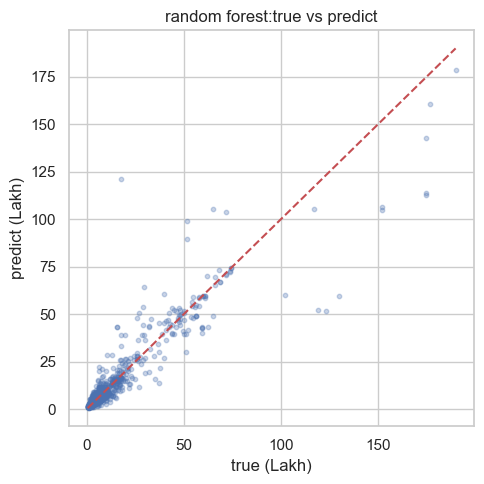

In [28]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('true (Lakh)')
plt.ylabel('predict (Lakh)')
plt.title('random forest:true vs predict')
plt.tight_layout()
plt.savefig(FIG_DIR/'06_rf_pred.png', dpi=120)
plt.show()


### 9.2 神经网络：多层感知机（MLP）回归


In [16]:
mlp_pipe = Pipeline([
    ('pre', preprocess),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(hidden_layer_sizes=(128,64,32), max_iter=400, random_state=RANDOM_STATE, early_stopping=True))
])
mlp_pipe.fit(X_train, y_train)
y_pred_mlp = mlp_pipe.predict(X_test)
metrics_mlp = regression_metrics(y_test, y_pred_mlp, 'MLP神经网络')
print('MLP 测试集指标:')
for k,v in metrics_mlp.items():
    print(f'  {k}: {v}')


MLP 测试集指标:
  模型: MLP神经网络
  MAE: 4.04
  MSE: 124.7425
  RMSE: 11.1688
  R2: 0.6903
  MAPE%: 37.8


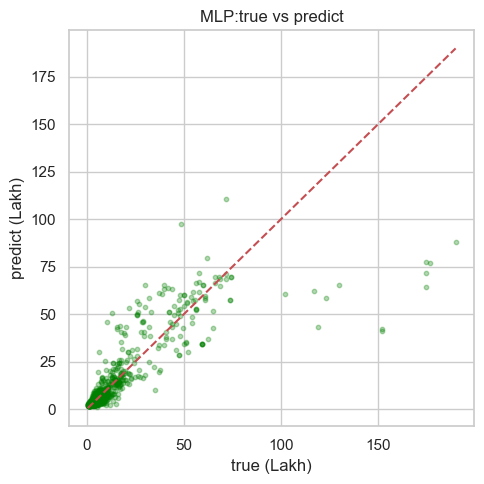

In [30]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_mlp, alpha=0.3, s=10, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('true (Lakh)')
plt.ylabel('predict (Lakh)')
plt.title('MLP:true vs predict')
plt.tight_layout()
plt.savefig(FIG_DIR/'07_mlp_pred.png', dpi=120)
plt.show()


### 9.3 模型效果对比


In [18]:
compare = pd.DataFrame([metrics_rf, metrics_mlp])
display(compare)
compare.to_csv(ROOT/'output'/'model_metrics.csv', index=False)


,模型,MAE,MSE,RMSE,R2,MAPE%
0,随机森林(传统ML),2.9448,59.6397,7.7227,0.8519,31.36
1,MLP神经网络,4.0400,124.7425,11.1688,0.6903,37.80


**对比分析（简要）**：

| 对比项 | 随机森林 | MLP 神经网络 |
|--------|----------|--------------|
| 对类别特征 | 原生支持，无需严格缩放 | 需 One-Hot + 标准化 |
| 非线性拟合 | 强，抗过拟合较好 | 强，但依赖样本量与调参 |
| 本数据集表现 | R² 通常更高、RMSE 更低 | 略逊，易欠拟合 |

**结论**：在印度二手车数据集上，**随机森林**往往优于默认结构的 MLP，原因包括：特征中类别变量多、样本约 5500 条对深层网络偏少、树模型对特征尺度不敏感。若继续优化神经网络，可增加训练轮次、调整隐藏层、使用嵌入层处理品牌等高基数特征。
